# 03-3 특성 공학과 규제
- feature: 농어의 길이, 높이, 두께, 농어 길이*농어 높이, ...
- target: 농어의 무게

In [1]:
# 판다스로 feature data 가져오기
import pandas as pd
perch_full = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [2]:
# target data
import numpy as np

perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])


In [3]:
# 훈련 세트와 테스트 세트로 나누기
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_full, perch_weight, random_state=42)

In [4]:
# 사이킷런 변환기(transformer) 사용해보기
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures()
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))

[[1. 2. 3. 4. 6. 9.]]


In [5]:
# 특성 데이터 확장
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
print(train_poly.shape)

# 특성 데이터 확인
poly.get_feature_names_out()

(42, 9)


array(['length', ' height', ' width', 'length^2', 'length  height',
       'length  width', ' height^2', ' height  width', ' width^2'],
      dtype=object)

In [6]:
# 테스트 데이터 변환
test_poly = poly.transform(test_input)

In [7]:
# 다중 회귀 모델 훈련하기
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, train_target)
print('훈련 세트:', lr.score(train_poly, train_target))
print('테스트 세트:', lr.score(test_poly, test_target))

훈련 세트: 0.9903183436982124
테스트 세트: 0.9714559911594145


In [8]:
# 특성을 더 많이 추가
poly = PolynomialFeatures(degree=5, include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
print(train_poly.shape) # train data shape 확인

(42, 55)


In [9]:
# 다시 훈련
lr.fit(train_poly, train_target)
print('훈련 세트:', lr.score(train_poly, train_target))
print('테스트 세트:', lr.score(test_poly, test_target)) # overfitting

훈련 세트: 0.9999999999996176
테스트 세트: -144.40585108215134


In [10]:
# 특성 데이터 정규화
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

## 릿지 회귀

In [11]:
# 릿지 모델 훈련
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_target)
print('훈련 세트:', ridge.score(train_scaled, train_target))
print('테스트 세트:', ridge.score(test_scaled, test_target))

훈련 세트: 0.9896101671037343
테스트 세트: 0.9790693977615379


In [12]:
# alpha 값에 대한 score 변화를 저장하는 리스트
import matplotlib.pyplot as plt
train_score = []
test_score = []

In [13]:
# alpha 값을 0.001에서 100까지 10배씩 늘려가며 릿지 회귀 모델 훈련
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    # 릿지 모델 만들기
    ridge = Ridge(alpha=alpha)
    # 릿지 모델 훈련
    ridge.fit(train_scaled, train_target)
    # 훈련 점수와 테스트 점수 저장
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

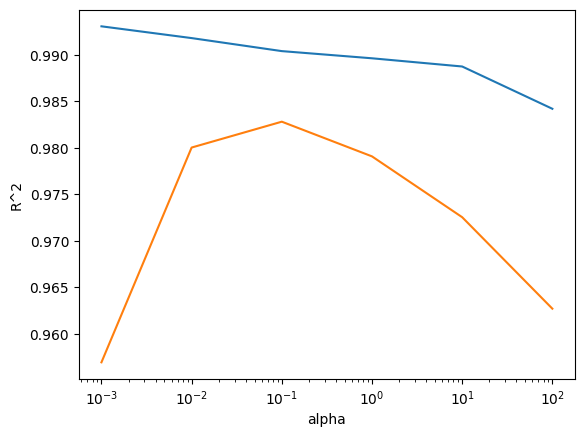

In [14]:
# alpha에 대한 훈련 점수 값 그래프
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

- 파란색: 훈련 세트 점수
- 주황색: 테스트세트 점수
- 최적의 $\alpha = 10^{-1}=0.1$
- 오른쪽으로 갈 수록 과소적합

In [15]:
# alpha = 0.1로 릿지 모델 훈련
ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)
print('훈련 세트:', ridge.score(train_scaled, train_target))
print('테스트 세트:', ridge.score(test_scaled, test_target))

훈련 세트: 0.9903815817570368
테스트 세트: 0.9827976465386983


## 라쏘 회귀

In [16]:
# 라쏘 모델 훈련
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(train_scaled, train_target)
print('훈련 세트:', lasso.score(train_scaled, train_target))
print('테스트 세트:', lasso.score(test_scaled, test_target))

훈련 세트: 0.989789897208096
테스트 세트: 0.9800593698421884


In [18]:
# 최적의 alpha값 찾기
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(train_scaled, train_target)
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

c:\Users\yeoji\Desktop\Machine Learning\ml_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\yeoji\Desktop\Machine Learning\ml_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


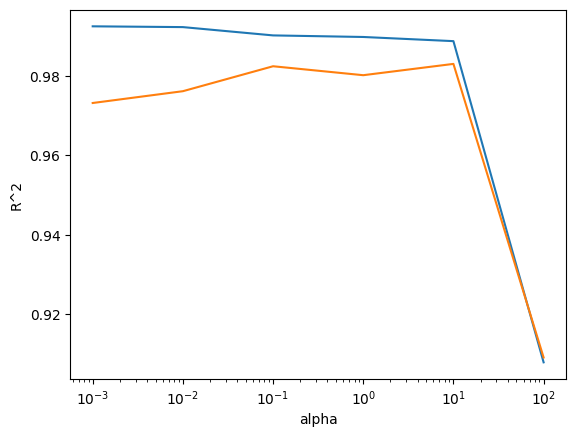

In [19]:
# 그래프 그리기
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

- 파란색: 훈련 세트
- 주황색: 테스트 세트
- 왼쪽은 과대적합, 오른쪽으로 갈 수록 점수 격차 좁아짐
- 가장 오른쪽은 점수가 크게 떨어짐
- 최적 $\alpha = 10^1 = 10$

In [20]:
# 최적의 alpha로 라쏘 모델 훈련
lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)
print('훈련 세트:', lasso.score(train_scaled, train_target))
print('테스트 세트:', lasso.score(test_scaled, test_target))

훈련 세트: 0.9888067471131866
테스트 세트: 0.9824470598706695
